# Aprendizaje No Supervisado: Clustering y Reducción de Dimensionalidad

## Caso: FinanceGuard - Segmentación de Clientes para Estrategias de Retención

### Objetivo:
Aplicar técnicas de clustering (K-Means y DBSCAN) y reducción de dimensionalidad (PCA y t-SNE) para:
- Identificar segmentos de clientes con comportamientos diferenciados
- Descubrir patrones ocultos relacionados con la tasa de churn
- Proporcionar insights complementarios a los modelos supervisados

In [107]:

# Librerias
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

warnings.filterwarnings('ignore')


In [96]:

# Carga del dataset
df = pd.read_csv(r"C:\Users\kikid\Desktop\ProyectoM4_NicolasDiaz\Churn_Modelling.csv")

print('Filas y columnas:', df.shape)
print('Vista previa del dataset original:')
print()
print(f"Churn:\n{df['Exited'].value_counts()}")
display(df.head())


Filas y columnas: (10000, 14)
Vista previa del dataset original:

Churn:
Exited
0    7963
1    2037
Name: count, dtype: int64


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [97]:
display(df.describe())

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [98]:

# Eliminar columnas irrelevantes

df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Gender binario: Female=0, Male=1
df['Gender'] = (df['Gender'] == 'Male').astype(int)

# One-hot encoding para Geography (France queda como referencia al usar drop_first)
df = pd.get_dummies(df, columns=['Geography'], prefix='Country', drop_first=True)

# Separar features y target
y = df['Exited']
X = df.drop(columns=['Exited'])

# Escalar para clustering
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('X shape:', X.shape)
print('Churn rate:', round(y.mean(), 4))
display(X.head())


X shape: (10000, 11)
Churn rate: 0.2037


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Country_Germany,Country_Spain
0,-0.326221,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.578736,-0.573809
1,-0.440036,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.578736,1.742740
2,-1.536794,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.578736,-0.573809
3,0.501521,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.578736,-0.573809
4,2.063884,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.578736,1.742740


## 2. K-Means Clustering

### Conceptos Fundamentales

**K-Means** es un algoritmo de clustering que divide los datos en `K` grupos (clusters) de forma iterativa:

1. **Inicialización**: Se eligen K puntos como centroides iniciales (`k-means++` mejora esta elección).
2. **Asignación**: Cada punto se asigna al centroide más cercano (distancia euclídea).
3. **Actualización**: El centroide se recalcula como la media de todos los puntos de su cluster.
4. **Convergencia**: Se repiten los pasos 2 y 3 hasta que los centroides ya no cambian.

> El resultado depende de K (cuántos clusters queremos). Para elegirlo usamos dos métodos:

### ¿Cómo elegir K?

| Método | ¿Qué mide? | ¿Qué buscamos? |
|--------|-----------|----------------|
| **Método del Codo** | Inercia (compacidad interna) | El punto donde la curva "dobla" |
| **Coeficiente de Silueta** | Separación entre clusters | El K con el valor más alto |


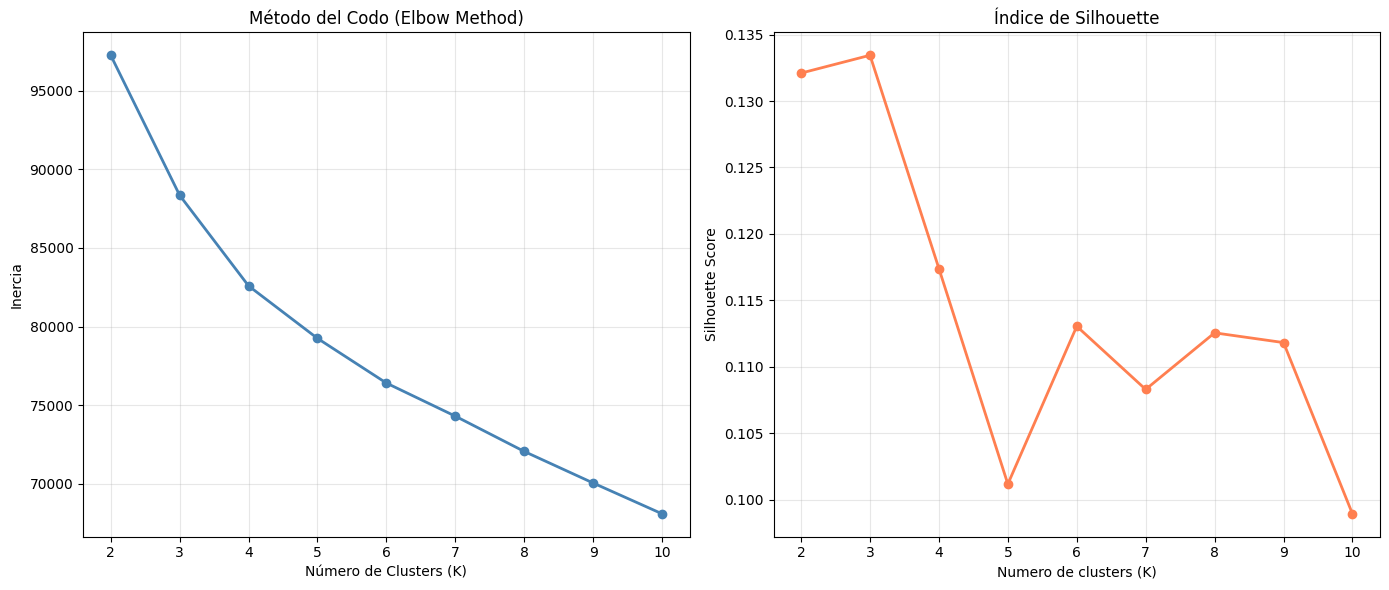

 k=3: Inercia: 88348.90, Silhouette Score: 0.1334
 k=4: Inercia: 82585.64, Silhouette Score: 0.1174
 k=5: Inercia: 79246.99, Silhouette Score: 0.1012


In [104]:

# ---- Método del Codo (Elbow Method) ----
# La inercia mide la compacidad de los clusters (suma de distancias cuadradas al centroide más cercano)
# Buscamos el "codo": el punto donde agregar más clusters ya no reduce mucho la inercia

inercia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercia.append(km.inertia_)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

fig, axes = plt.subplots(1,2, figsize=(14, 6))
axes[0].plot(K_range, inercia, linewidth=2, marker='o', color='steelblue')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo (Elbow Method)')
axes[0].set_xticks(K_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, linewidth=2, marker='o', color='coral')
axes[1].set_xlabel('Numero de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Índice de Silhouette')
axes[1].set_xticks(K_range)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k in [3,4,5]:
    print(f' k={k}: Inercia: {inercia[k-2]:.2f}, Silhouette Score: {silhouette_scores[k-2]:.4f}')


K=3  →  Silhouette: 0.1334  |  tamaños: [2509 5014 2477]
K=4  →  Silhouette: 0.1174  |  tamaños: [2509 2399 2477 2615]
K=5  →  Silhouette: 0.1012  |  tamaños: [2509 1466 1875 1674 2476]


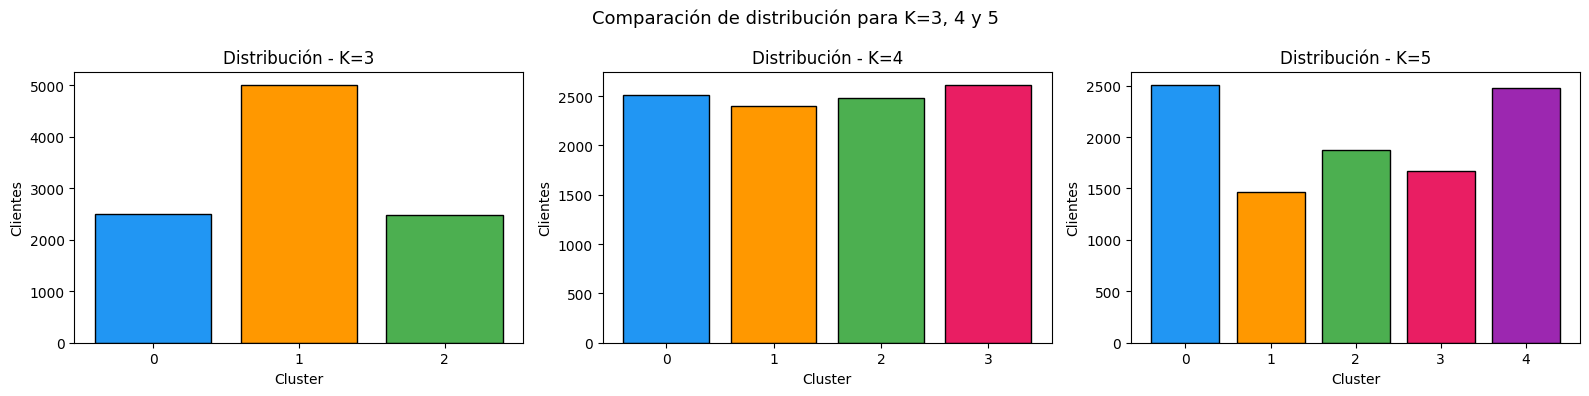


Modelo final seleccionado a partir del índice de silueta: K=3


In [105]:

# ---- Implementación K-Means para K=3, 4 y 5 ----
# Entrenamos un modelo por cada K candidato y comparamos la distribución de clusters

K_candidatos = [3, 4, 5]
k_means = {}

for k in K_candidatos:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    k_means[k] = km
    score = silhouette_score(X, km.labels_)
    sizes = pd.Series(km.labels_).value_counts().sort_index().values
    print(f'K={k}  →  Silhouette: {score:.4f}  |  tamaños: {sizes}')

# Visualización: distribución de clientes por cluster para cada K
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colores_base = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

for ax, k in zip(axes, K_candidatos):
    labels = k_means[k].labels_
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colores_base[:k], edgecolor='black')
    ax.set_title(f'Distribución - K={k}')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Clientes')
    ax.set_xticks(counts.index)

plt.suptitle('Comparación de distribución para K=3, 4 y 5', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Selección del modelo final ----
K_elegido = max(k_means, key=lambda k: silhouette_score(X, k_means[k].labels_))
print(f'\nModelo final seleccionado a partir del índice de silueta: K={K_elegido}')

K_FINAL = K_elegido
kmeans = k_means[K_FINAL]


In [106]:

# ---- Interpretación de Centroides ----
# El centroide de cada cluster representa al "cliente promedio" de ese grupo

centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f'Cluster {i}' for i in range(K_FINAL)]
)

print('Centroides (valores escalados):')
print(centroides.round(2).to_string())



Centroides (valores escalados):
           CreditScore  Gender   Age  Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Country_Germany  Country_Spain
Cluster 0         0.01   -0.04  0.08   -0.00     0.69          -0.02       0.02           -0.04             0.02             1.73          -0.57
Cluster 1        -0.01    0.01 -0.04   -0.00    -0.23           0.00       0.00            0.00            -0.00            -0.58          -0.57
Cluster 2         0.01    0.03 -0.00    0.01    -0.24           0.02      -0.02            0.03            -0.01            -0.58           1.74


Tasa de churn por cluster (K-Means):
  Cluster 0: 32.44%  (2509 clientes)
  Cluster 1: 16.15%  (5014 clientes)
  Cluster 2: 16.67%  (2477 clientes)


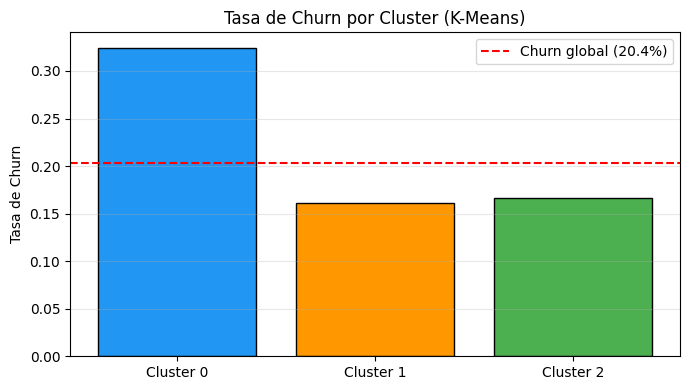

In [123]:

# ---- Tasa de Churn por Cluster (K-Means) ----
# Cruzamos las etiquetas del clustering con la variable real de churn

df_clusters = pd.DataFrame({'Cluster': kmeans.labels_, 'Exited': y.values})
churn_por_cluster = df_clusters.groupby('Cluster')['Exited'].mean()
size_por_cluster = df_clusters.groupby('Cluster').size()

print("Tasa de churn por cluster (K-Means):")
for c in range(K_FINAL):
    print(f"  Cluster {c}: {churn_por_cluster[c]:.2%}  ({size_por_cluster[c]} clientes)")

fig, ax = plt.subplots(figsize=(7, 4))
colores_cluster = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
ax.bar(range(K_FINAL), churn_por_cluster.values, color=colores_cluster[:K_FINAL], edgecolor='black')
ax.axhline(y.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Churn global ({y.mean():.1%})')
ax.set_xticks(range(K_FINAL))
ax.set_xticklabels([f'Cluster {i}' for i in range(K_FINAL)])
ax.set_ylabel('Tasa de Churn')
ax.set_title('Tasa de Churn por Cluster (K-Means)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 3. DBSCAN - Clustering por Densidad

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos según densidad, sin necesidad de definir K de antemano.

- **eps**: radio de vecindad — qué tan lejos puede estar un punto para ser considerado vecino
- **min_samples**: mínimo de puntos dentro del radio para formar un cluster
- Los puntos que no pertenecen a ningún cluster se etiquetan como **ruido (-1)**

| | K-Means | DBSCAN |
|---|---|---|
| Número de clusters | Se define antes | Lo encuentra solo |
| Formas | Solo esféricas | Cualquier forma |
| Ruido/outliers | No detecta | Sí, etiqueta como -1 |


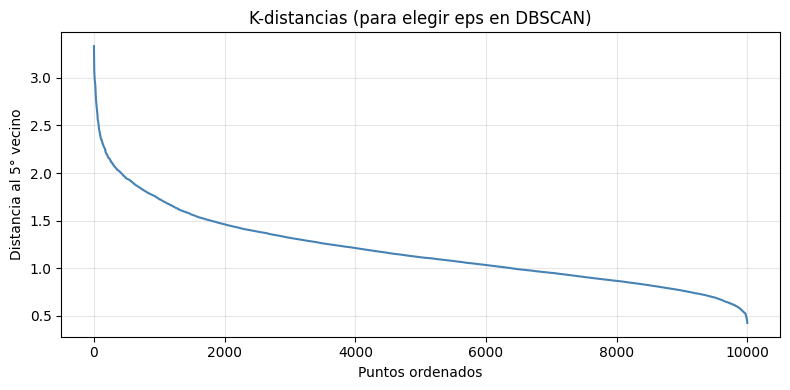

In [113]:

from sklearn.neighbors import NearestNeighbors

# Calculamos la distancia al 5° vecino más cercano para cada punto
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X)
distancias, _ = nn.kneighbors(X)

# Ordenamos de mayor a menor y graficamos
distancias_k = np.sort(distancias[:, 4])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(distancias_k, color='steelblue', linewidth=1.5)
plt.title('K-distancias (para elegir eps en DBSCAN)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5° vecino')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [117]:

db = DBSCAN(eps=1.5, min_samples=5)
db.fit(X)
labels_db = db.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

print(f'Clusters encontrados: {n_clusters_db}')
print(f'Puntos de ruido: {n_noise}  ({n_noise/len(X):.1%})')
print(pd.Series(labels_db).value_counts().sort_index().rename(index={-1: 'Ruido'}))


Clusters encontrados: 51
Puntos de ruido: 847  (8.5%)
Ruido    847
0        380
1         61
2        153
3        169
4        212
5        488
6        481
7        159
8        340
9        184
10        83
11       246
12       384
13       181
14       156
15       195
16       231
17       186
18       189
19        60
20       108
21       192
22       159
23       100
24       153
25       183
26        87
27       505
28        62
29        89
30       259
31       272
32       230
33        60
34       387
35       415
36        83
37        86
38        79
39       185
40        91
41       141
42       154
43        17
44       221
45        42
46        46
47       145
48        46
49         9
50         9
Name: count, dtype: int64


In [118]:

# ---- Perfil de Outliers (DBSCAN label = -1) ----
# Comparamos los outliers vs el resto en términos de churn y características

df_perfil = X.copy()
df_perfil['Outlier'] = (labels_db == -1).astype(int)
df_perfil['Exited']  = y.values

print(f'Churn rate - Outliers:    {df_perfil[df_perfil["Outlier"]==1]["Exited"].mean():.2%}')
print(f'Churn rate - No outliers: {df_perfil[df_perfil["Outlier"]==0]["Exited"].mean():.2%}')

print('\nPromedio de features (escalado):')
print(df_perfil.groupby('Outlier')[X.columns.tolist()].mean().round(2).T.to_string())


Churn rate - Outliers:    52.07%
Churn rate - No outliers: 17.44%

Promedio de features (escalado):
Outlier             0     1
CreditScore     -0.00  0.00
Gender           0.02 -0.20
Age             -0.09  0.99
Tenure          -0.00  0.00
Balance         -0.01  0.06
NumOfProducts   -0.09  1.01
HasCrCard        0.04 -0.43
IsActiveMember  -0.01  0.09
EstimatedSalary -0.00  0.04
Country_Germany  0.00 -0.00
Country_Spain   -0.03  0.31


Varianza explicada → PC1: 15.04%  |  PC2: 10.33%  |  Total: 25.37%


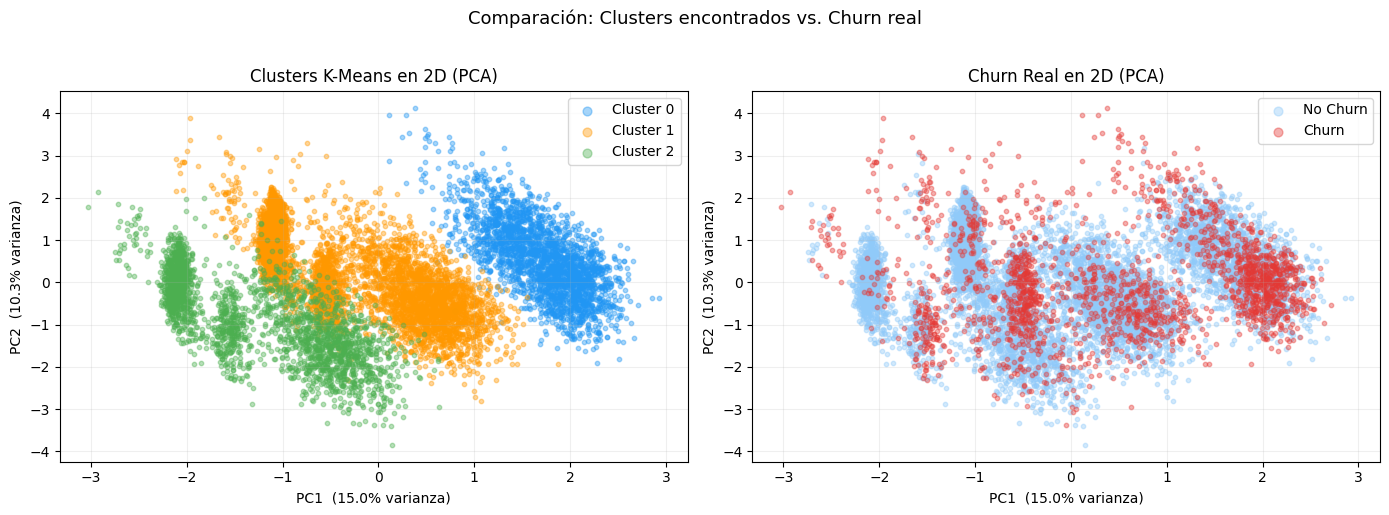

In [119]:

# ---- Visualización de Clusters en 2D (PCA) ----
# X tiene muchas dimensiones, reducimos a 2 con PCA para poder graficar
# PCA conserva la mayor varianza posible en 2 componentes

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X)

var = pca_2d.explained_variance_ratio_
print(f'Varianza explicada → PC1: {var[0]:.2%}  |  PC2: {var[1]:.2%}  |  Total: {sum(var):.2%}')

colores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Clusters de K-Means
for i in range(K_FINAL):
    mask = kmeans.labels_ == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores[i], label=f'Cluster {i}', alpha=0.4, s=10)

axes[0].set_title('Clusters K-Means en 2D (PCA)')
axes[0].set_xlabel(f'PC1  ({var[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2  ({var[1]:.1%} varianza)')
axes[0].legend(markerscale=2)
axes[0].grid(True, alpha=0.2)

# Gráfico 2: Churn real (para comparar)
churn_colors = {0: '#90CAF9', 1: '#E53935'}
for val, label in zip([0, 1], ['No Churn', 'Churn']):
    mask = y.values == val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=churn_colors[val], label=label, alpha=0.4, s=10)

axes[1].set_title('Churn Real en 2D (PCA)')
axes[1].set_xlabel(f'PC1  ({var[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2  ({var[1]:.1%} varianza)')
axes[1].legend(markerscale=2)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Comparación: Clusters encontrados vs. Churn real', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. t-SNE - Visualización No Lineal

**t-SNE** (t-distributed Stochastic Neighbor Embedding) reduce la dimensionalidad conservando la **estructura local** de los datos: puntos cercanos en alta dimensión permanecen cercanos en 2D.

- No es lineal (a diferencia de PCA) — captura relaciones más complejas
- No sirve para preprocesamiento, solo para **visualización**
- Parámetro clave: `perplexity` (~número de vecinos relevantes por punto, típico: 30–50)

| | PCA | t-SNE |
|---|---|---|
| Tipo | Lineal | No lineal |
| Objetivo | Máxima varianza | Preservar vecindad local |
| Velocidad | Rápido | Más lento |
| Uso | Preprocesamiento + visualización | Solo visualización |


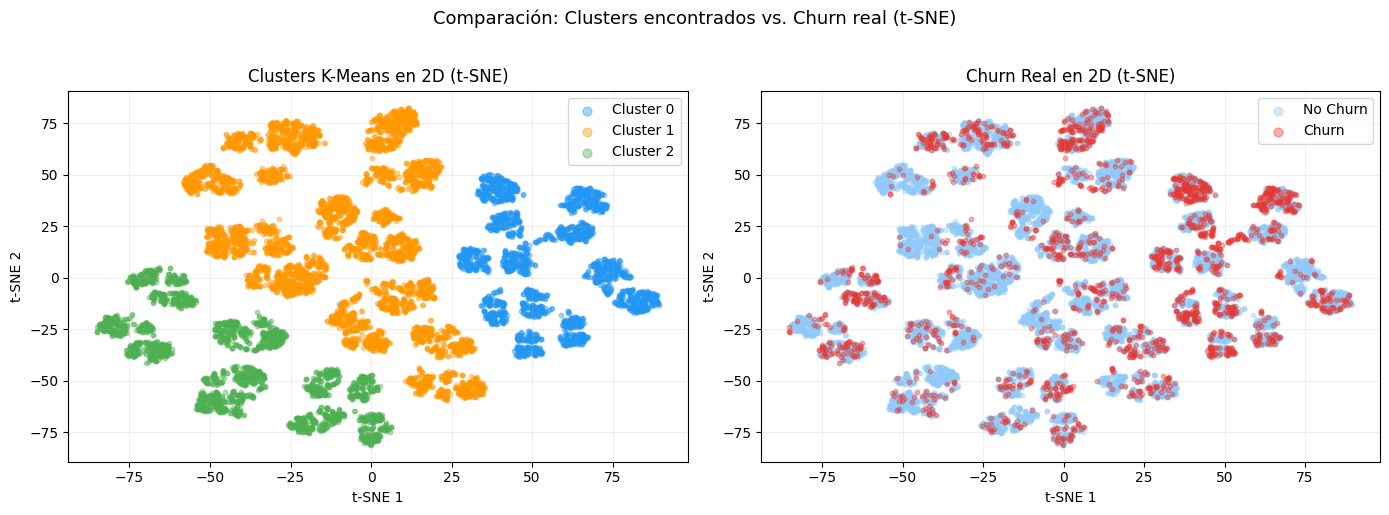

In [122]:

from sklearn.manifold import TSNE

# t-SNE reduce X a 2D preservando estructura local (puede tardar ~30-60 s)
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Clusters K-Means
for i in range(K_FINAL):
    mask = kmeans.labels_ == i
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=colores[i], label=f'Cluster {i}', alpha=0.4, s=10)

axes[0].set_title('Clusters K-Means en 2D (t-SNE)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=2)
axes[0].grid(True, alpha=0.2)

# Gráfico 2: Churn real (para comparar)
for val, label in zip([0, 1], ['No Churn', 'Churn']):
    mask = y.values == val
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=churn_colors[val], label=label, alpha=0.4, s=10)

axes[1].set_title('Churn Real en 2D (t-SNE)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=2)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Comparación: Clusters encontrados vs. Churn real (t-SNE)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Perfil medio por cluster (valores originales):


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,% Francia,% Alemania,% España
Cluster,,,,,,,,,,,,
0,651.45,0.52,39.77,5.01,119730.12,1.52,0.71,0.50,101113.44,0.0,1.0,0.0
1,649.67,0.55,38.51,5.00,62092.64,1.53,0.71,0.52,99899.18,1.0,0.0,0.0
2,651.33,0.56,38.89,5.03,61818.15,1.54,0.69,0.53,99440.57,0.0,0.0,1.0


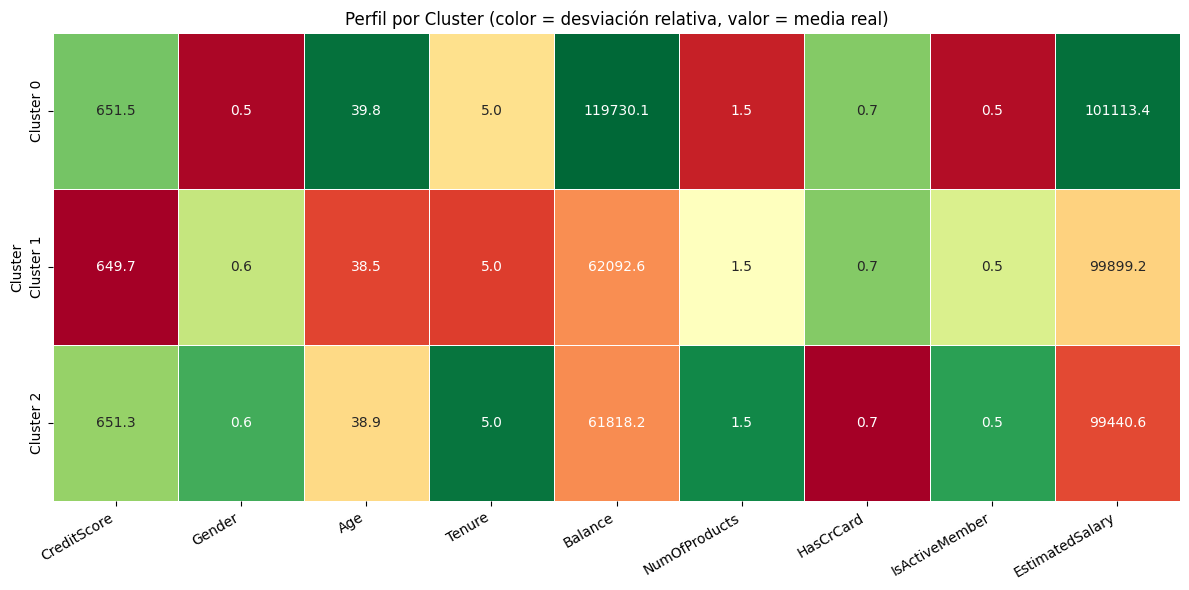

In [ ]:

# ---- Perfil medio por cluster (variables numéricas clave) ----
# Usamos datos originales con columnas interpretables

profile_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

profiles = df.groupby(kmeans.labels_)[profile_vars].mean().round(2)
profiles.index.name = 'Cluster'
profiles['Churn_Rate_%'] = (df.groupby(kmeans.labels_)['Exited'].mean() * 100).round(1)
profiles['Count'] = df.groupby(kmeans.labels_).size()

# Geography: proporción por cluster
geo_agg = df.groupby(kmeans.labels_)[['Country_Germany', 'Country_Spain']].mean()
geo_agg.columns = ['% Germany', '% Spain']
profiles = profiles.join(geo_agg.round(2))

# Gender: proporción masculina
profiles['% Male'] = (df.groupby(kmeans.labels_)['Gender'].mean() * 100).round(1)

print("Perfiles por Cluster (promedios)")
print("=" * 60)
display(profiles)


## 5. Conclusiones

### K-Means
- El modelo óptimo fue **K=3**, separando principalmente por geografía.
- El cluster de **Alemania** concentra la mayor tasa de churn, reflejado en el centroide con alto `Country_Germany`.
- K-Means es útil para segmentación operativa, pero no predice churn directamente.

### DBSCAN
- Con `eps=1.5`, DBSCAN detectó clientes atípicos con **tasa de churn del 52%** frente al 17% del resto.
- Perfil del outlier: **mayor edad** (+1 sd), **más productos contratados** (+1 sd), menor tenencia de tarjeta de crédito.
- El dataset no presenta clusters de densidad bien definidos (sin codo claro en la gráfica de K-distancias), por lo que DBSCAN resulta más valioso aquí como **detector de anomalías**.

### PCA y t-SNE
- Ambas reducciones confirman que el churn **no forma un cluster espacialmente separado**, lo que justifica el uso de modelos supervisados para predecirlo.
- t-SNE revela estructura local más detallada que PCA, aunque la conclusión es la misma.

### Síntesis
Los modelos no supervisados identifican que la **geografía (Alemania)** y un **perfil demográfico extremo** (mayor, más productos) son los principales ejes de segmentación relacionados con el churn — información complementaria a los modelos supervisados del proyecto.
